<a href="https://colab.research.google.com/github/jopraetaro-1/acpapp/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_curve, roc_auc_score


In [ ]:
# 1. Load Data
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
print("ตัวอย่างข้อมูล:\n", df.head())


ตัวอย่างข้อมูล:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
# 2. เตรียมข้อมูล
x = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

In [ ]:
# 3. Normalize ข้อมูล (0-1)
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [ ]:
# 4. แยกข้อมูล Train-Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

In [ ]:
# 5. สร้างโมเดล Neural Network (ANN)
model = Sequential()
model.add(Dense(16, input_dim=8, activation='relu'))  # ชั้นซ่อน (Hidden Layer) 16 units
model.add(Dense(8, activation='relu'))  # ชั้นซ่อนอีกชั้น
model.add(Dense(1, activation='sigmoid'))  # Output สำหรับ Binary Classification

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 6. Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# 7. เทรนโมเดล พร้อมแสดง Progress Bar (Epoch)
history = model.fit(x_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_test, y_test),
    verbose=1  )

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3452 - loss: 0.8742 - val_accuracy: 0.3571 - val_loss: 0.7760
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3834 - loss: 0.7389 - val_accuracy: 0.5130 - val_loss: 0.6941
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5787 - loss: 0.6842 - val_accuracy: 0.6721 - val_loss: 0.6655
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6224 - loss: 0.6710 - val_accuracy: 0.6688 - val_loss: 0.6539
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6366 - loss: 0.6655 - val_accuracy: 0.6688 - val_loss: 0.6485
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6602 - loss: 0.6540 - val_accuracy: 0.6688 - val_loss: 0.6445
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6238 - loss: 0.6637 - val_accuracy: 0.6688 - val_loss: 0.6420
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6264 - loss: 0.6599 - val_accuracy: 0.6688 

In [ ]:
# 8. สรุปผล Training (Loss, Accuracy)
print("\nสรุปผล Training:")
final_loss, final_acc = model.evaluate(x_test, y_test)
print(f"Loss: {final_loss:.4f}, Accuracy: {final_acc:.4f}")


สรุปผล Training:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5250 
Loss: 0.4848, Accuracy: 0.7857


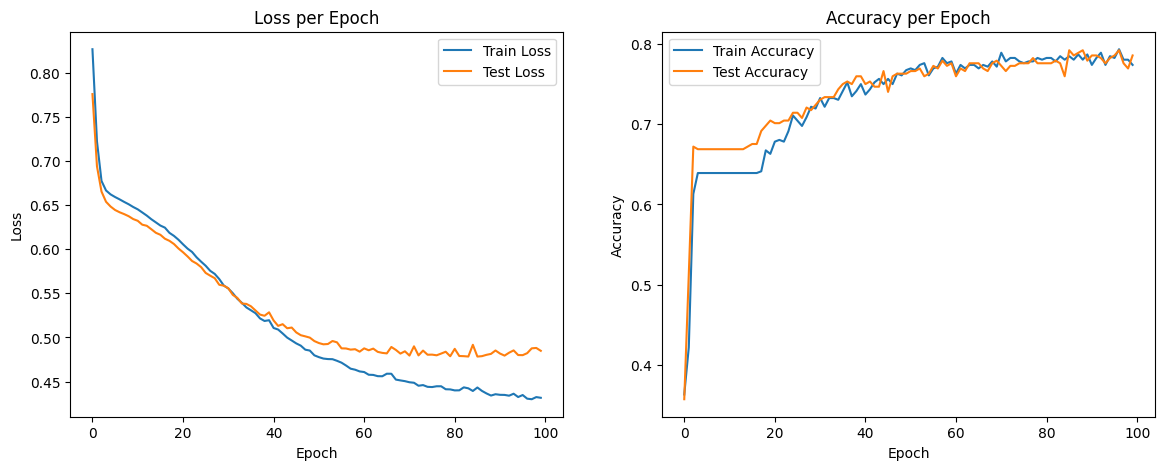

In [ ]:
# 9. แสดงกราฟ Loss และ Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# 10. ประเมินผล (Confusion Matrix, Report)
y_pred_prob = model.predict(x_test)  # ได้ค่า probability
y_pred = (y_pred_prob > 0.5).astype(int)  # ตัดเกณฑ์ 0.5 เป็น 0/1

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84       206
           1       0.68      0.67      0.67       102

    accuracy                           0.79       308
   macro avg       0.76      0.76      0.76       308
weighted avg       0.78      0.79      0.79       308


Confusion Matrix:
 [[174  32]
 [ 34  68]]


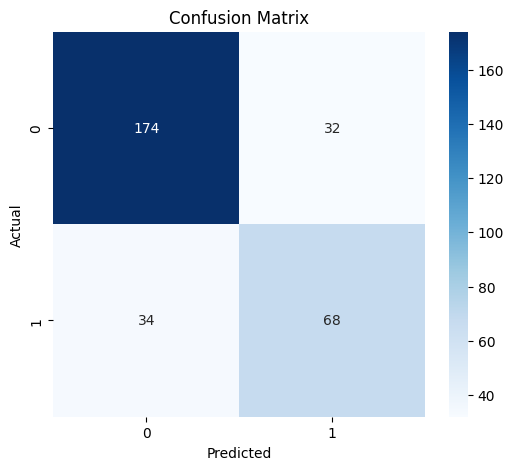

In [ ]:
# 11. วาด Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.save('my_diabetes_model.h5')  # เซฟเป็นไฟล์ชื่อ my_diabetes_model.h5


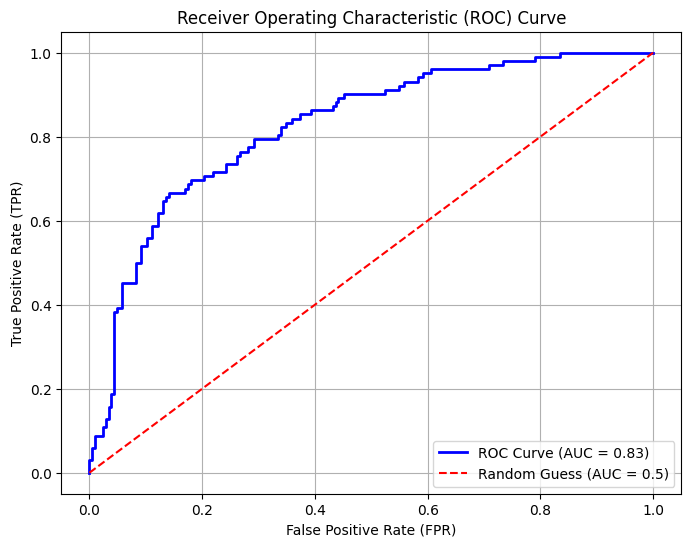

In [ ]:
# 12. วาด ROC Curve และแสดงค่า AUC
from sklearn.metrics import roc_curve, roc_auc_score

# คำนวณค่า FPR, TPR สำหรับ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# คำนวณค่า AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)

# วาดกราฟ ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
# 🔽 ติดตั้ง Gradio (สำหรับสร้าง Web UI บน Colab)
!pip install gradio

# ✅ โหลด Model และ Library ที่จำเป็น
import gradio as gr
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 📊 1. Load Data
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')

# 🧹 2. เตรียมข้อมูล
x = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# 🔄 3. Normalize ข้อมูล (0-1)
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

# ✂️ 4. แยกข้อมูล Train-Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

# 🧠 5. สร้างโมเดล ANN
model = Sequential()
model.add(Dense(16, input_dim=8, activation='relu'))  # Hidden Layer 1
model.add(Dense(8, activation='relu'))               # Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))           # Output Layer

# ⚙️ 6. Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# 🚀 7. Train Model
history = model.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_test, y_test), verbose=0)  # ไม่แสดง log

# ✅ 8. ฟังก์ชันสำหรับทำนายผลเบาหวาน
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree, age):
    # สร้างข้อมูลในรูปแบบที่โมเดลต้องการ
    input_data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree, age]])

    # ทำ normalization เช่นเดียวกับที่ทำกับ training data
    input_data_scaled = scaler.transform(input_data)

    # ทำนายผล
    prediction = model.predict(input_data_scaled)[0][0]  # เอาค่า probability ออกมา

    # แปลงผลลัพธ์เป็นข้อความภาษาอังกฤษ
    if prediction > 0.5:
        return "You are likely to have diabetes."
    else:
        return "You are unlikely to have diabetes."

# 🌐 9. สร้าง Interface ด้วย Gradio
interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Skin Thickness"),
        gr.Number(label="Insulin"),
        gr.Number(label="BMI"),
        gr.Number(label="Diabetes Pedigree Function"),
        gr.Number(label="Age"),
    ],
    outputs="text",
    title="Diabetes Detection Website",
    description="Fill in your medical data to check if you are likely to have diabetes or not."
)

# ✅ 10. เรียกใช้ Web Interface
interface.launch(share=True)  # share=True เพื่อให้ได้ลิงก์สำหรับแชร์


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
to

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7f77c9204a33daf0b5.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# 📊 Load Data and Train Model as usual
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
x = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

scaler = MinMaxScaler()
x = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

model = Sequential()
model.add(Dense(16, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_test, y_test), verbose=0)

# ✅ Function สำหรับรับข้อมูลแบบกรอกทีเดียว
def predict_diabetes(input_text):
    try:
        # แยก string เป็น list of numbers
        values = [float(x.strip()) for x in input_text.split(",")]

        if len(values) != 8:
            return "❌ Please enter exactly 8 numbers separated by commas."

        # แปลงและ normalize
        input_data = np.array([values])  # ทำเป็น 2D array
        input_data_scaled = scaler.transform(input_data)

        # ทำนาย
        prediction = model.predict(input_data_scaled)[0][0]

        # ตีความผล
        if prediction > 0.5:
            return "✅ You are likely to have diabetes."
        else:
            return "✅ You are unlikely to have diabetes."

    except ValueError:
        return "❌ Invalid input. Please enter numbers separated by commas."

# 🌐 สร้าง Gradio Interface
interface = gr.Interface(
    fn=predict_diabetes,
    inputs=gr.Textbox(lines=2, placeholder="Example: 2, 120, 70, 20, 79, 25.6, 0.351, 29", label="Enter 8 numbers (comma-separated)"),
    outputs="text",
    title="Diabetes Detection Website",
    description="Fill in 8 medical values separated by commas. Example: 2, 120, 70, 20, 79, 25.6, 0.351, 29"
)

# ✅ Run
interface.launch(share=True)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://475690d65cda35d53d.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# 🔽 ติดตั้ง Gradio ก่อน (เฉพาะใน Google Colab เท่านั้น)
!pip install gradio

# ✅ Import libraries
import gradio as gr
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 📊 Load Dataset
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')

# ✅ เตรียมข้อมูล
x = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# ✅ Normalize
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

# ✅ แยก Train-Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

# ✅ สร้างและฝึก Model
model = Sequential()
model.add(Dense(16, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_test, y_test), verbose=0)

# ✅ ฟังก์ชันสำหรับทำนายผล
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree, age):
    try:
        # สร้าง array ข้อมูล
        input_data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree, age]])

        # Normalize เหมือนตอนฝึก
        input_data_scaled = scaler.transform(input_data)

        # ทำนายผล
        prediction = model.predict(input_data_scaled)[0][0]

        # ตีความผลลัพธ์
        if prediction > 0.5:
            return "✅ You are likely to have diabetes."
        else:
            return "✅ You are unlikely to have diabetes."

    except Exception as e:
        return f"❌ Error: {str(e)}"

# ✅ สร้าง Gradio Interface แบบ 8 ช่องกรอกแยกกัน
interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Skin Thickness"),
        gr.Number(label="Insulin"),
        gr.Number(label="BMI"),
        gr.Number(label="Diabetes Pedigree Function"),
        gr.Number(label="Age"),
    ],
    outputs="text",
    title="Diabetes Detection Website",
    description="Fill in your medical data below to check if you are likely to have diabetes or not."
)

# ✅ เรียกใช้งานเว็บไซต์
interface.launch(share=True)  # share=True จะได้ลิงก์ไปใช้งาน


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6a656468765e3e19f.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ✅ ติดตั้ง Gradio (ถ้ายังไม่ติดตั้งใน Colab)
!pip install gradio

# ✅ Import libraries
import gradio as gr
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ✅ Load dataset
df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')

# ✅ เตรียมข้อมูล
x = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# ✅ Normalize ข้อมูล
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

# ✅ แยก Train-Test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

# ✅ สร้างและฝึกโมเดล ANN
model = Sequential()
model.add(Dense(16, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=100, batch_size=16, validation_data=(x_test, y_test), verbose=0)

# ✅ Function สำหรับทำนายเบาหวาน
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree, age):
    try:
        # รวมค่าที่ผู้ใช้กรอก
        input_data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree, age]])

        # Normalize ข้อมูลเหมือนตอน Train
        input_data_scaled = scaler.transform(input_data)

        # ทำนายผล
        prediction = model.predict(input_data_scaled)[0][0]

        # ตีความผลลัพธ์
        if prediction > 0.5:
            return "✅ You are likely to have diabetes."
        else:
            return "✅ You are unlikely to have diabetes."

    except Exception as e:
        return f"❌ Error: {str(e)}"

# ✅ สร้างหน้าเว็บแบบกรอกช่องละค่า (เหมือนที่ต้องการ)
interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies (จำนวนครั้งที่ตั้งครรภ์)"),
        gr.Number(label="Glucose (ระดับน้ำตาลกลูโคส)"),
        gr.Number(label="Blood Pressure (ความดันโลหิต)"),
        gr.Number(label="Skin Thickness (ความหนาของผิวหนัง)"),
        gr.Number(label="Insulin (ระดับอินซูลิน)"),
        gr.Number(label="BMI (ค่าดัชนีมวลกาย)"),
        gr.Number(label="Diabetes Pedigree Function (ความบกพร่องทางพันธุกรรม)"),
        gr.Number(label="Age (อายุ)"),
    ],
    outputs="text",
    title="🩺 Diabetes Detection Website",
    description="กรอกค่าต่าง ๆ เพื่อทำนายว่าคุณมีแนวโน้มจะเป็นเบาหวานหรือไม่ (กรอกเป็นตัวเลขเท่านั้น)"
)

# ✅ เรียกใช้งาน
interface.launch(share=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
tor

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c405e9c9dc91475551.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
